C:\Users\Prime\AppData\Local\Temp\ipykernel_20960\2134575825.py:5: DtypeWarning: Columns (0: vehicle_id, 1: vehicle_lane, 2: vehicle_type) have mixed types. Specify dtype option on import or set low_memory=False.
  fcd = pd.read_csv("fcd.csv", sep=";")


Average speed (km/h): 15.907962185618961
Total CO2: 706565028.9499999


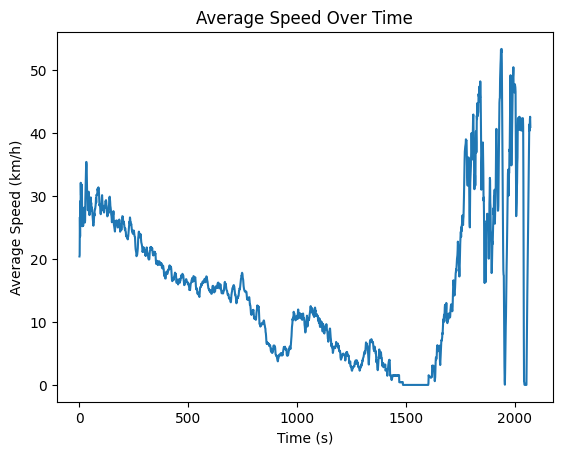

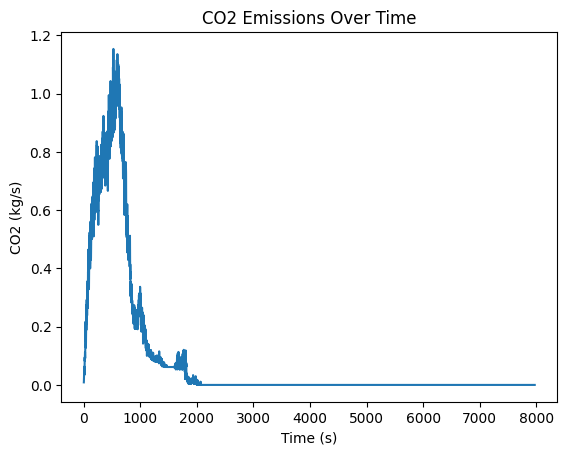

In [5]:
import pandas as pd
import matplotlib.pyplot as plt

# Load data
fcd = pd.read_csv("fcd.csv", sep=";")
emission = pd.read_csv("emission.csv", sep=";")

# Merge
df = pd.merge(fcd, emission, on=["timestep_time", "vehicle_id"])

# --- CONVERT SPEED TO km/h ---
df["speed_kmh"] = df["vehicle_speed_x"] * 3.6

# --- BASIC METRICS ---
avg_speed_kmh = df["speed_kmh"].mean()
print("Average speed (km/h):", avg_speed_kmh)

total_co2 = df["vehicle_CO2"].sum()
print("Total CO2:", total_co2)

# --- TIME SERIES ---
speed_time = df.groupby("timestep_time")["speed_kmh"].mean()
co2_time = df.groupby("timestep_time")["vehicle_CO2"].sum() / 1e6

# --- PLOTS ---

# Speed over time (km/h)
plt.figure()
plt.plot(speed_time.index, speed_time.values)
plt.xlabel("Time (s)")
plt.ylabel("Average Speed (km/h)")
plt.title("Average Speed Over Time")
plt.show()

# CO2 over time
plt.figure()
plt.plot(co2_time.index, co2_time.values)
plt.xlabel("Time (s)")
plt.ylabel("CO2 (kg/s)")
plt.title("CO2 Emissions Over Time")
plt.show()